## This the Project which contain Data Cleaning , EDA, Feature Engineering

### Step 1: Import Libraries

In [179]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import(
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    TargetEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler
)


### Step 2: Load Dataset

In [180]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Step 3: Basic Inspection

In [181]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [182]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [183]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
259,1,2,female,50.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
729,0,3,female,25.0,1,0,7.9250,S,Third,woman,False,NaN,Southampton,no,False
290,1,1,female,26.0,0,0,78.8500,S,First,woman,False,NaN,Southampton,yes,True


In [184]:
df.shape

(891, 15)

In [185]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [187]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [188]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [189]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

### Step 4: Check Missing Values

In [190]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [191]:
# (df.isna().sum() / len(df)) * 100
df.isna().mean()*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

### Step 5: Duplicate Records

In [192]:
df.duplicated().sum()

np.int64(107)

In [193]:
df = df.drop_duplicates()

In [194]:
df.duplicated().sum()

np.int64(0)

### Step 6: Check Unique Values

In [195]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print("-"*50)

survived
2
[0 1]
--------------------------------------------------
pclass
3
[3 1 2]
--------------------------------------------------
sex
2
['male' 'female']
--------------------------------------------------
age
88
[22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]
--------------------------------------------------
sibsp
7
[1 0 3 4 2 5 8]
--------------------------------------------------
parch
7
[0 1 2 5 3 4 6]
--------------------------------------------------
fare
248
[  7.25    71.2833   7.925   53.1      8.05

### Step 7: Data Cleaning

### Age

In [196]:
df['age'].fillna(df['age'].median(), inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_23996\1654433547.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


### Embarked

In [197]:
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_23996\1964997694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


### Deck

In [198]:
print(df['deck'].cat.categories)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype='object')


In [199]:
df['deck'] = df['deck'].cat.add_categories('Unknown')
df['deck'].fillna('Unknown', inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_23996\1630194201.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['deck'].fillna('Unknown', inplace=True)


In [200]:
print(df['deck'].cat.categories)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown'], dtype='object')


In [201]:
df['deck'].isna().sum()

np.int64(0)

### Embark Town

In [202]:
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_23996\395761809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)


In [203]:
df['embark_town'].isna().sum()

np.int64(0)

### Drop Column

In [204]:
df.drop(columns='alive', inplace=True)

### Step 8: Outlier Detection

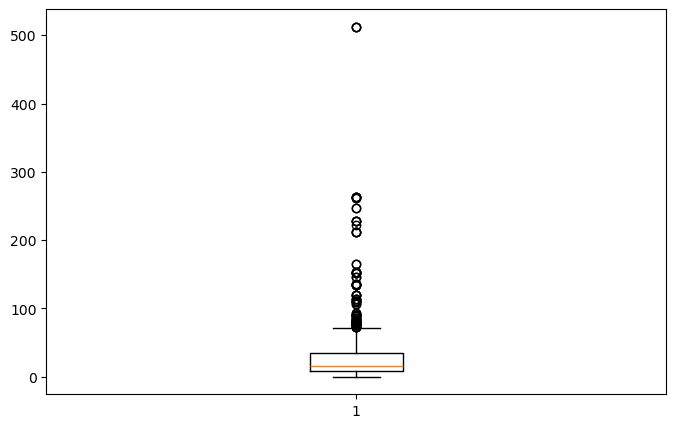

In [205]:
plt.figure(figsize=(8,5))
plt.boxplot(df['fare'])
plt.show()

### Step 9: Handle Outliers (IQR)

In [211]:
Q1 = df['fare'].quantile(.25)
Q3 = df['fare'].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]

In [212]:
outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
27,0,1,male,19.00,3,2,263.0000,S,First,man,True,C,Southampton,False
31,1,1,female,28.25,1,0,146.5208,C,First,woman,False,B,Cherbourg,False
34,0,1,male,28.00,1,0,82.1708,C,First,man,True,Unknown,Cherbourg,False
52,1,1,female,49.00,1,0,76.7292,C,First,woman,False,D,Cherbourg,False
61,1,1,female,38.00,0,0,80.0000,S,First,woman,False,B,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.00,0,0,80.0000,S,First,woman,False,B,Southampton,True
835,1,1,female,39.00,1,1,83.1583,C,First,woman,False,E,Cherbourg,False
849,1,1,female,28.25,1,0,89.1042,C,First,woman,False,C,Cherbourg,False
856,1,1,female,45.00,1,1,164.8667,S,First,woman,False,Unknown,Southampton,False


In [ ]:
# this code filter the outliers
df = df[(df['fare']>=lower)&(df['fare']<=upper)]

In [218]:
df['fare'].describe()

count    682.000000
mean      19.507490
std       14.836515
min        0.000000
25%        7.895800
50%       13.000000
75%       26.550000
max       71.283300
Name: fare, dtype: float64

### Step 10: Univariate Analysis

### Numerical

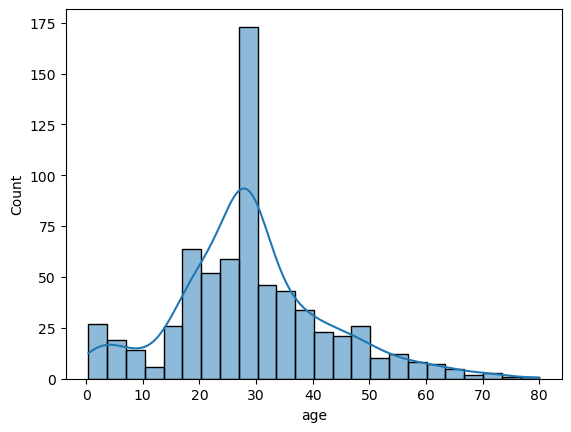

In [215]:
sns.histplot(df['age'], kde=True)
plt.show()

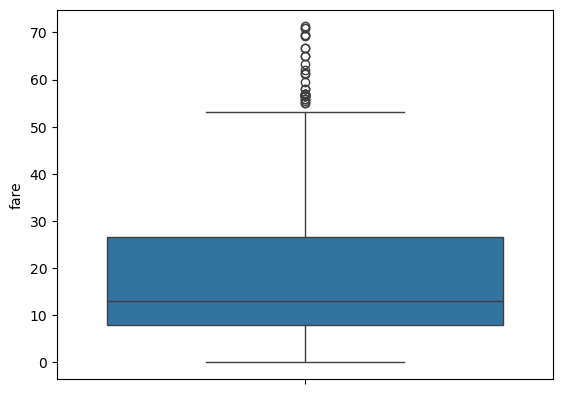

In [216]:
sns.boxplot(df['fare'])
plt.show()

### Categorical

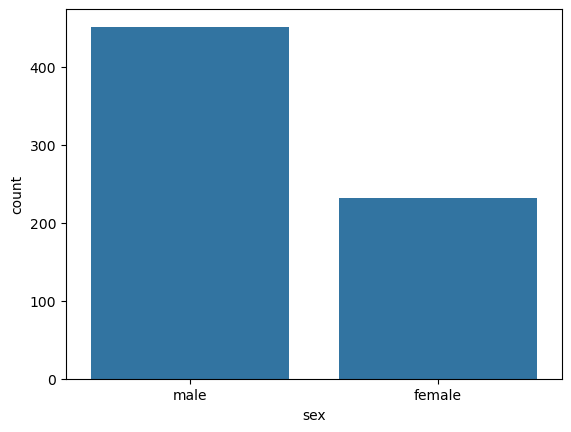

In [219]:
sns.countplot(x='sex', data=df)
plt.show()

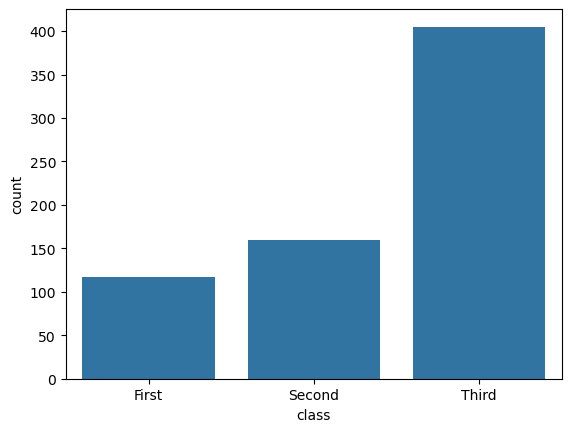

In [220]:
sns.countplot(x='class', data=df)
plt.show()

### Step 11: Bivariate Analysis

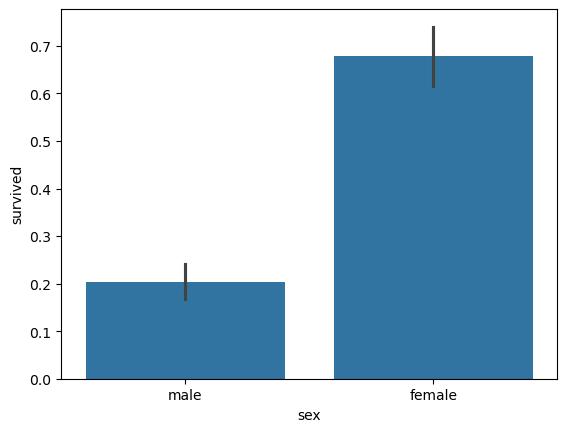

In [221]:
sns.barplot(x='sex', y='survived', data=df)
plt.show()

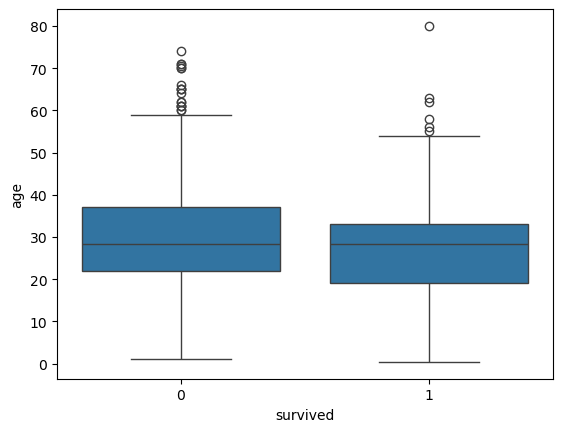

In [222]:
sns.boxplot(x='survived', y='age', data=df)
plt.show()

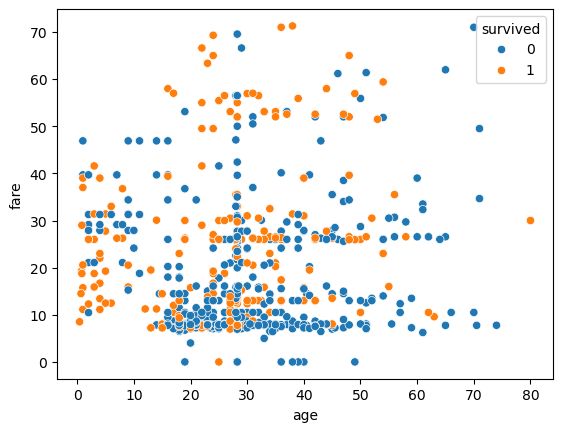

In [223]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.show()

### Step 12: Multivariate Analysis

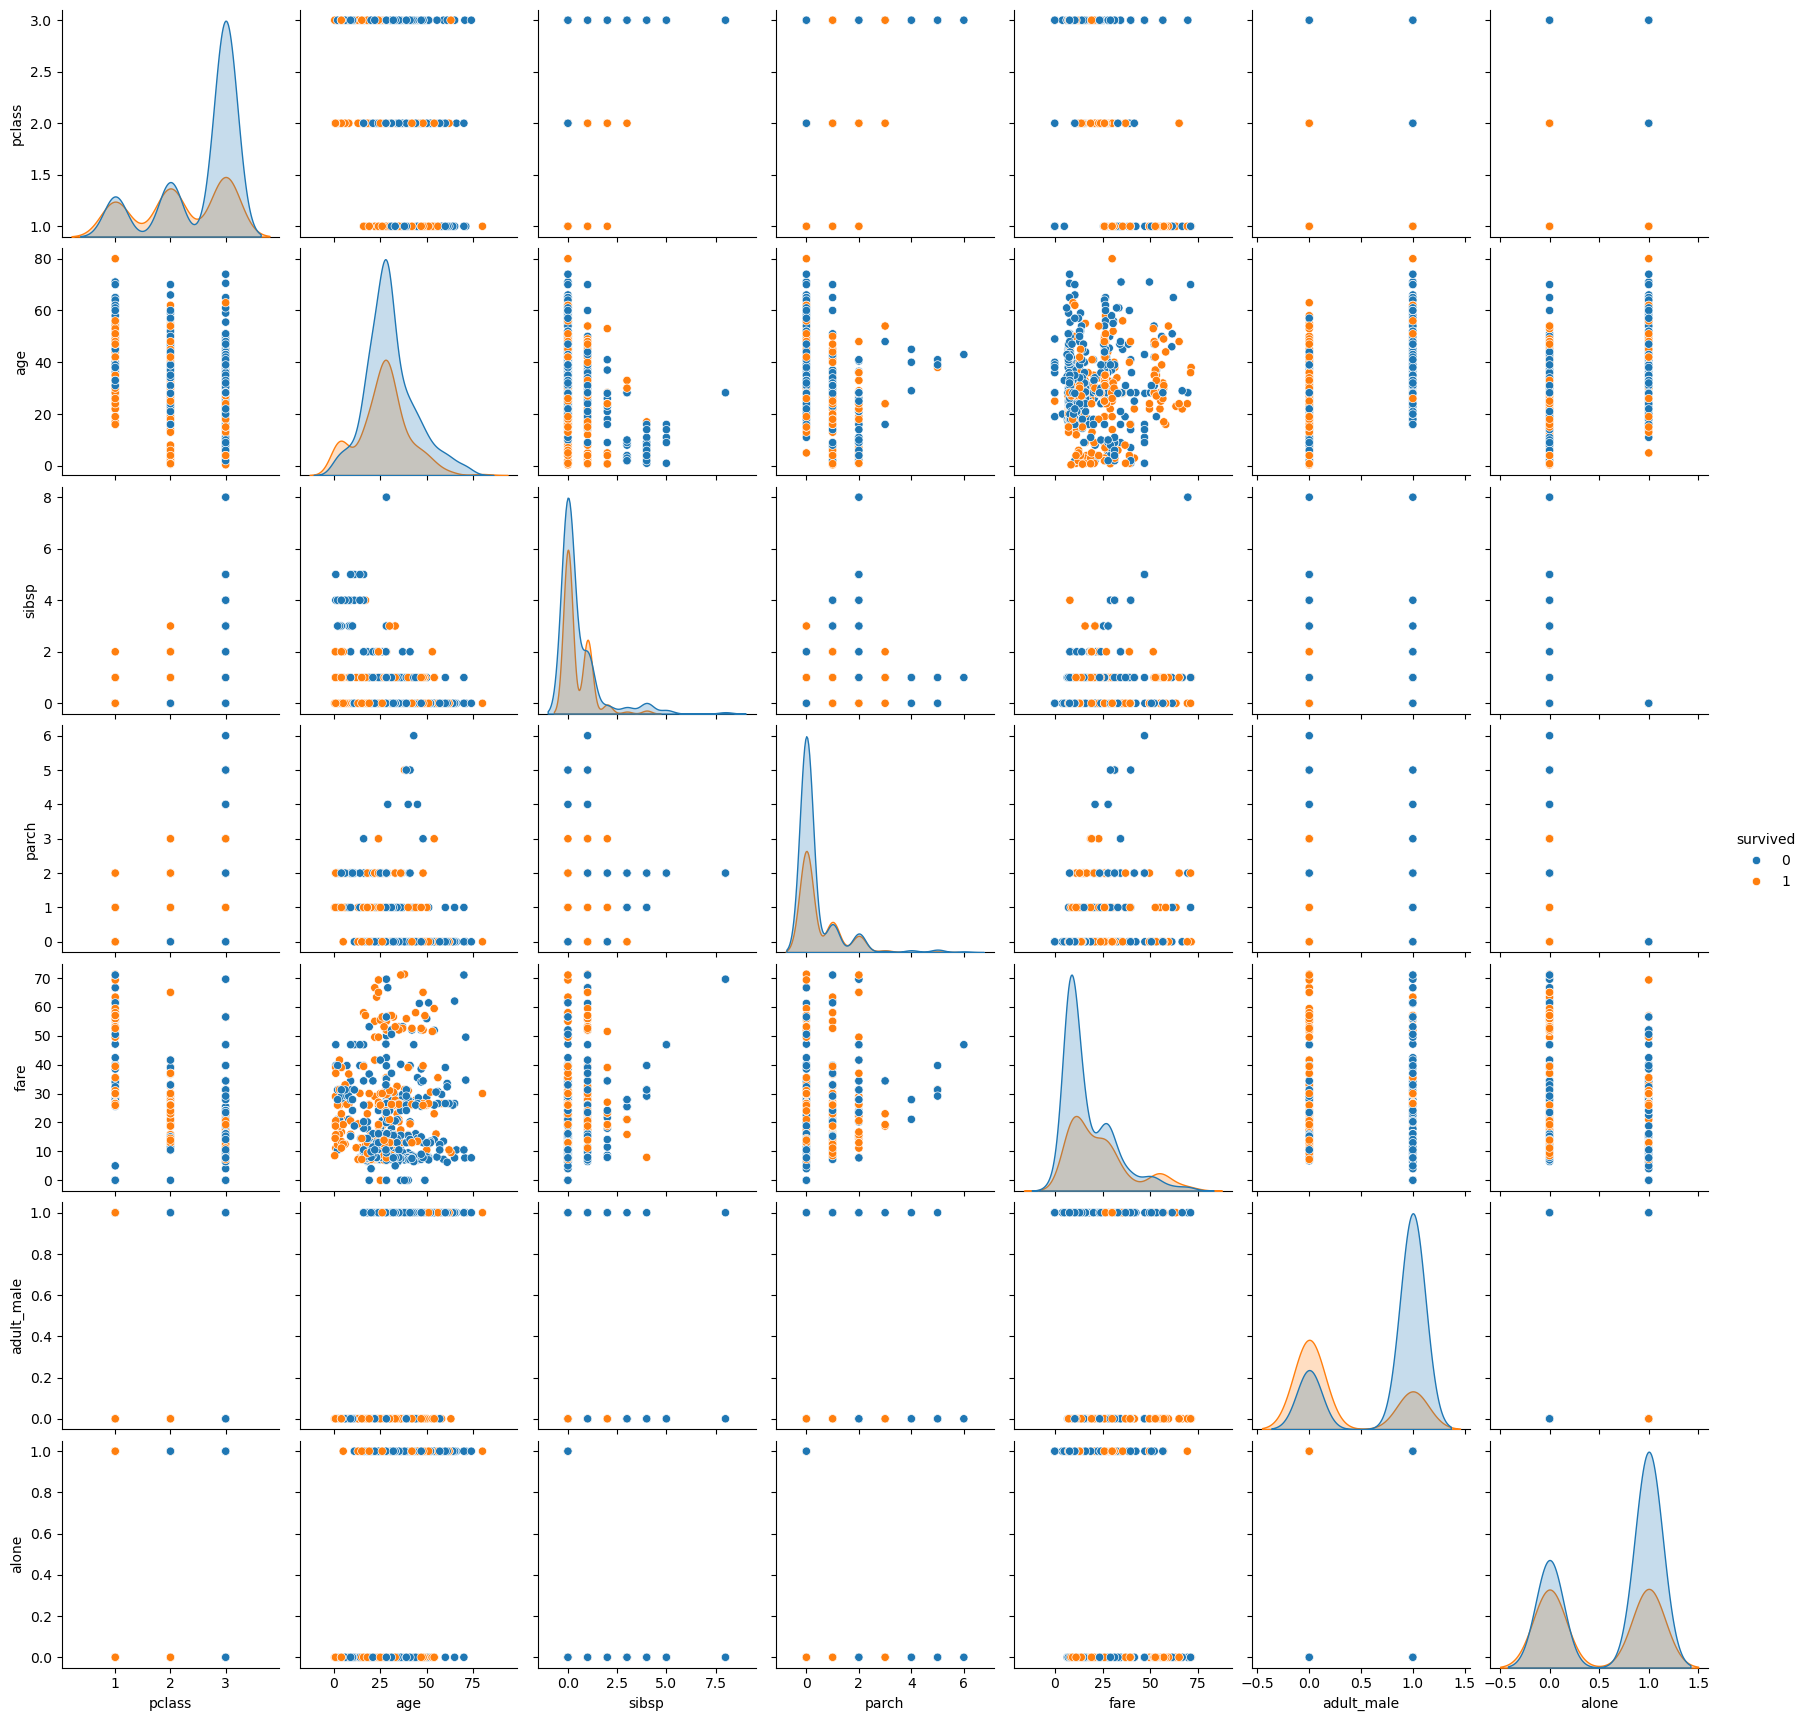

In [227]:
sns.pairplot(df,hue='survived')

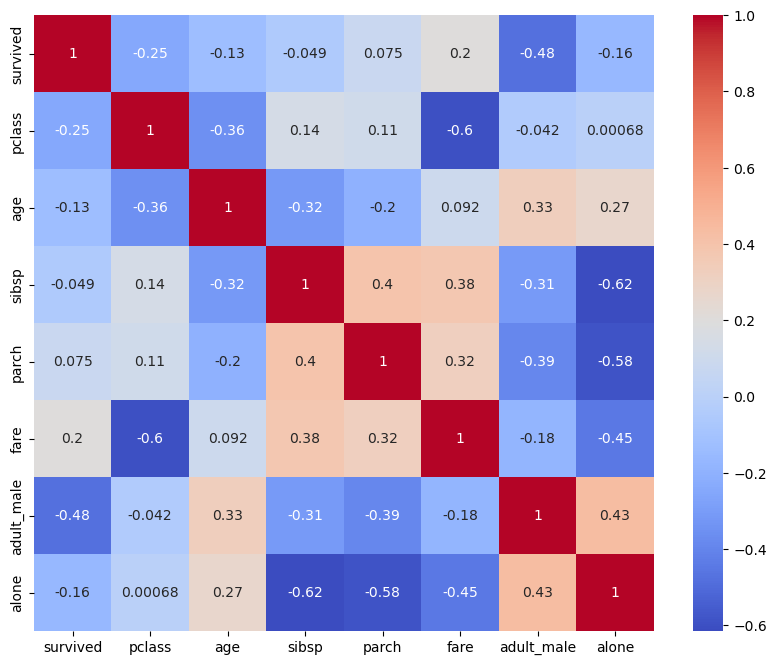

In [228]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

### Step 13: Feature Engineering